### Regularization

the overarching term for any technique that intentionally makes a model's training process harder in order to prevent it from memorizing the data (Overfitting).


Mathematically, standard Regularization works by modifying your Loss Function. Instead of just calculating the Error, we add a Penalty for Complexity.

$$Total\_Loss = Error(y, \hat{y}) + \lambda \cdot Penalty(W)$$

$Error(y, \hat{y})$: How wrong the prediction was (e.g., MSE or Cross-Entropy).

$Penalty(W)$: A mathematical punishment based on the size of the network's weights ($W$).

$\lambda$ (Lambda): The regularization strength. If $\lambda$ is 0.0, there is no penalty. If $\lambda$ is 0.1, the penalty is heavy.

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# lambda parameter (how strict the penalty is). 
# 0.01 or 0.001 are standard starting points.
l2_strength = 0.01 

model = tf.keras.Sequential([
    layers.Input(shape=(10,)),
    
    # Apply L2 Regularization to this specific layer's weights
    layers.Dense(
        64, 
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_strength) 
    ),
    
    layers.Dense(1, activation='linear')
])

##### Early Stopping

Early Stopping is a form of regularization used in iterative machine learning algorithms (like Neural Networks) that halts the training process the moment the model's performance on a separate, unseen validation dataset begins to degrade, rather than waiting to finish a predetermined number of epochs.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X,y = make_circles(n_samples=100,noise=0.1,random_state=1)

In [6]:
X

array([[-0.63640493, -0.36870191],
       [-0.24465976, -0.73659196],
       [-0.46597138, -1.06687743],
       [-0.70999784, -0.40841948],
       [ 0.70232238, -0.51730147],
       [-0.49776571,  0.76955129],
       [-0.31914906, -0.84899624],
       [-0.57839322, -0.49081236],
       [-0.53350227,  0.58056527],
       [-0.24733259,  0.73011595],
       [ 0.41030774, -0.73075986],
       [ 0.17181003, -0.92504802],
       [ 0.65917045,  0.62120588],
       [ 0.87625577,  0.12510879],
       [ 0.81946243, -0.01347859],
       [-0.47960986, -0.7880243 ],
       [-0.90187751, -0.70895455],
       [ 0.74827659, -0.55976747],
       [-0.74875324, -0.37153443],
       [ 0.23161178,  1.01205842],
       [ 0.81387506,  0.22821311],
       [-0.92169575,  0.20310719],
       [ 0.74650434, -0.35861224],
       [ 0.01330079,  0.68169193],
       [-0.72651409,  0.58630948],
       [-0.33930852, -1.0080984 ],
       [ 0.49009938, -0.62509577],
       [-0.9539309 , -0.33410313],
       [ 0.6927241 ,

<Axes: >

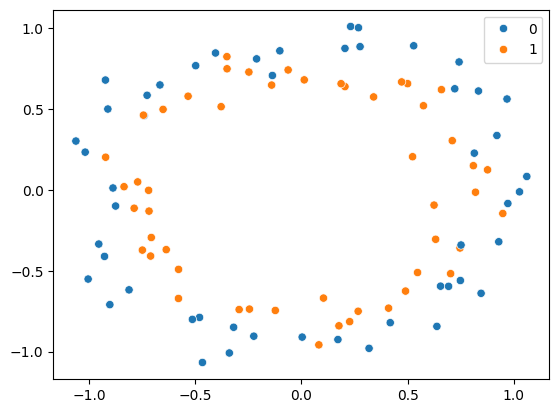

In [11]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256,input_dim=2,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=['accuracy'])

In [19]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=350)

Epoch 1/350


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8250 - loss: 0.5202 - val_accuracy: 0.5500 - val_loss: 0.6832
Epoch 2/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8250 - loss: 0.5187 - val_accuracy: 0.5500 - val_loss: 0.6805
Epoch 3/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8250 - loss: 0.5170 - val_accuracy: 0.5500 - val_loss: 0.6781
Epoch 4/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8375 - loss: 0.5156 - val_accuracy: 0.5500 - val_loss: 0.6750
Epoch 5/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8375 - loss: 0.5145 - val_accuracy: 0.5500 - val_loss: 0.6741
Epoch 6/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8375 - loss: 0.5135 - val_accuracy: 0.5500 - val_loss: 0.6751
Epoch 7/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8375 - loss: 0.5118 - val_accuracy: 0.5500 - val_loss: 0.6752
Epoch 8/350
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8375 - loss: 0.5106 - val_accuracy: 0.5500 - val_loss: 0.6758
E

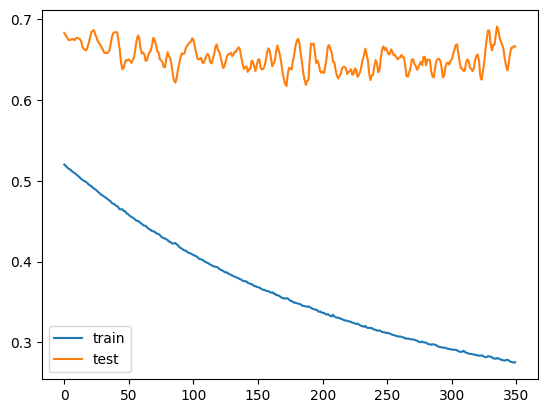

In [20]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256,input_dim=2,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

In [24]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [25]:
callback = EarlyStopping(
    # 1. monitor: The specific metric the "referee" is watching. 
    # Usually "val_loss" (Validation Loss) because that tells you if it is overfitting.
    monitor="val_loss",
    
    # 2. min_delta: The minimum amount of change required to count as an "improvement".
    # If the loss only drops by 0.000001, it is basically statistical noise. 
    # Setting this to 0.00001 means "Don't reset the patience timer unless it actually took a real step forward."
    min_delta=0.00001,
    
    # 3. patience: The number of epochs with no improvement the referee will tolerate.
    # If the model fails to improve the val_loss by at least 0.00001 for 20 epochs in a row, 
    # the kill switch is flipped, and training aborts.
    patience=20,
    
    # 4. verbose: Controls what is printed to your console.
    # 0 = Silent mode. 
    # 1 = Prints a clean message like "Epoch 00050: early stopping" when it triggers.
    verbose=1,
    
    # 5. mode: Does the monitor want the number to go UP or DOWN?
    # "min" = You want it to drop (used for Loss/Error).
    # "max" = You want it to rise (used for Accuracy/Precision).
    # "auto" = TensorFlow guesses based on the name of the monitor (e.g., it knows "loss" should go down).
    mode="auto",
    
    # 6. baseline: A hard target the model MUST reach to survive.
    # If baseline=0.5, and the model's loss never drops below 0.5, training will abort 
    # after the patience timer runs out, even if the model was slowly improving. 
    # None = No hard target. Just keep improving from wherever you started.
    baseline=None,
    
    # 7. restore_best_weights: THE MOST IMPORTANT PARAMETER.
    # False (The Default): When training stops, the model keeps the weights from the EXACT epoch it died on (Epoch 50). 
    # Because it spent the last 20 epochs degrading (your patience window), these weights are highly overfitted and terrible!
    # True (What you should use): The model throws away the last 20 epochs of garbage and restores the weights from the exact moment it hit its highest score (Epoch 30).
    restore_best_weights=False 
)

In [26]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.5125 - loss: 0.6891 - val_accuracy: 0.4000 - val_loss: 0.7018
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5375 - loss: 0.6870 - val_accuracy: 0.3500 - val_loss: 0.7087
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5375 - loss: 0.6845 - val_accuracy: 0.3500 - val_loss: 0.7129
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.5375 - loss: 0.6823 - val_accuracy: 0.3500 - val_loss: 0.7154
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5375 - loss: 0.6813 - val_accuracy: 0.3500 - val_loss: 0.7186
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5375 - loss: 0.6805 - val_accuracy: 0.3500 - val_loss: 0.7212
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5375 - loss: 0.6793 - val_accuracy: 0.3500 - val_loss: 0.7226
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5375 - loss: 0.6786 - val_accuracy: 0.35

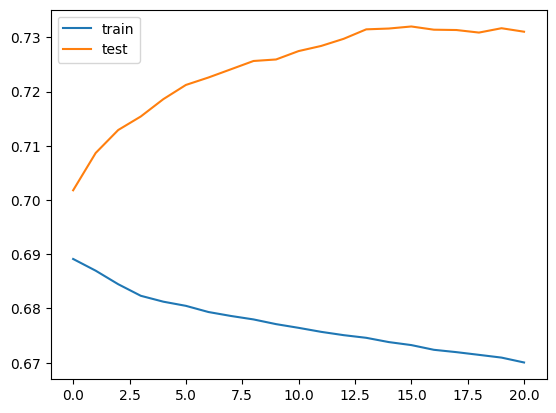

In [27]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()